# Continuous-Age Model Comparison

This notebook is the experiment-first analysis for the current stroke screening direction.

**Use case**: stroke risk screening support, not diagnosis.

**Primary objective**: maximise recall and reduce false negatives, while using precision, F1, and ROC-AUC as supporting metrics.


## Why This Notebook Exists

The production pipeline should stay in `.py` modules. This notebook exists to test the current modelling direction in a controlled and explainable way before those decisions are locked back into `ml/train.py`.

The notebook focuses on four questions:
1. Does the continuous-age preprocessing flow look sound on the real dataset?
2. How do the four current candidate models compare on a validation split under a recall-first screening objective?
3. Which validation threshold gives the strongest recall-oriented operating point without precision collapsing?
4. Does light hyperparameter tuning materially change the validation ranking before one final holdout test?

In [22]:
# Setup block.
# The goal of this cell is to gather every import and every global constant in
# one place so the rest of the notebook reads like a sequence of clear steps.
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown, display

from imblearn.ensemble import BalancedRandomForestClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.preprocessing import StandardScaler

try:
    import matplotlib.pyplot as plt  # noqa: F401
except ImportError:
    plt = None

try:
    import seaborn as sns  # noqa: F401
except ImportError:
    sns = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:0.4f}")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "stroke-data.csv"

TARGET_COLUMN = "stroke"

# Keep 0.30 as a visible baseline because the current project already uses it.
# The notebook later checks whether validation data supports a better threshold.
SCREENING_THRESHOLD = 0.30
RANDOM_STATE = 42
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAINVAL = 0.25

# The threshold search is dense enough to show tradeoffs clearly without making
# the notebook visually noisy.
THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.05), 2) #?

RAW_INPUT_FIELDS = ["age", "gender", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "smoking_status"]
SELECTED_FEATURES = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "gender_other", "smoking_status_formerly smoked", "smoking_status_smokes", "smoking_status_Unknown"]
SCALED_FEATURES = ["age", "avg_glucose_level", "bmi"]

MODEL_REGISTRY = {
    "logistic": {
        "label": "Logistic Regression",
        "factory": lambda: LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),#? factory
        "uses_scaled_features": True,
    },
    "balanced_rf": {
        "label": "Balanced Random Forest",
        "factory": lambda: BalancedRandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
        "uses_scaled_features": False,
    },
    "random_forest": {
        "label": "Random Forest",
        "factory": lambda: RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "uses_scaled_features": False,
    },
    "gradient_boosting": {
        "label": "Gradient Boosting",
        "factory": lambda: GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
        "uses_scaled_features": False,
    },
}

DATA_PATH

WindowsPath('C:/Users/rkrb1/stroke_prediction/stroke-prediction-system/data/stroke-data.csv')

## Data Audit

This section checks the real dataset before any transformation logic is applied. The point is to ground the modelling work in the actual data shape, class imbalance, and missing-value pattern rather than assuming those conditions from memory.

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1
1,51676,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,NaN,never smoked,1
2,31112,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1
3,60182,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1
4,1665,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1


,metric,value
0,rows,5110.0000
1,columns,12.0000
2,positive_cases,249.0000
3,negative_cases,4861.0000
4,positive_rate,0.0487


,column,missing_count,missing_pct
9,bmi,201,0.0393
0,id,0,0.0000
1,gender,0,0.0000
2,age,0,0.0000
3,hypertension,0,0.0000
4,heart_disease,0,0.0000
5,ever_married,0,0.0000
6,work_type,0,0.0000
7,Residence_type,0,0.0000
8,avg_glucose_level,0,0.0000


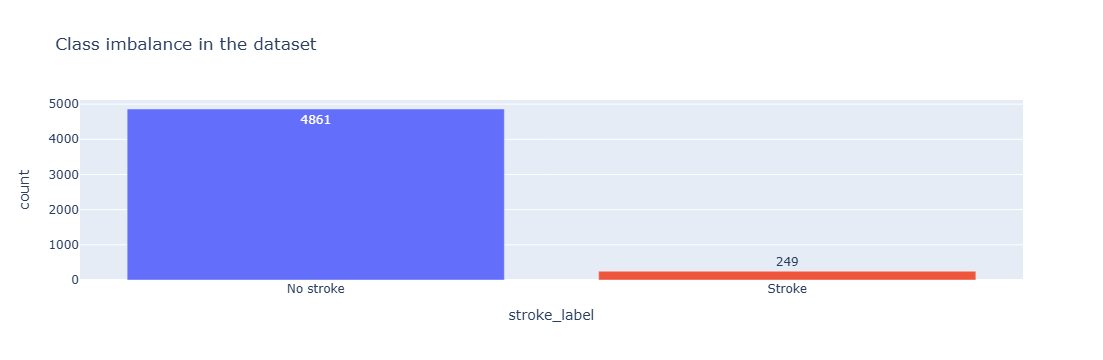

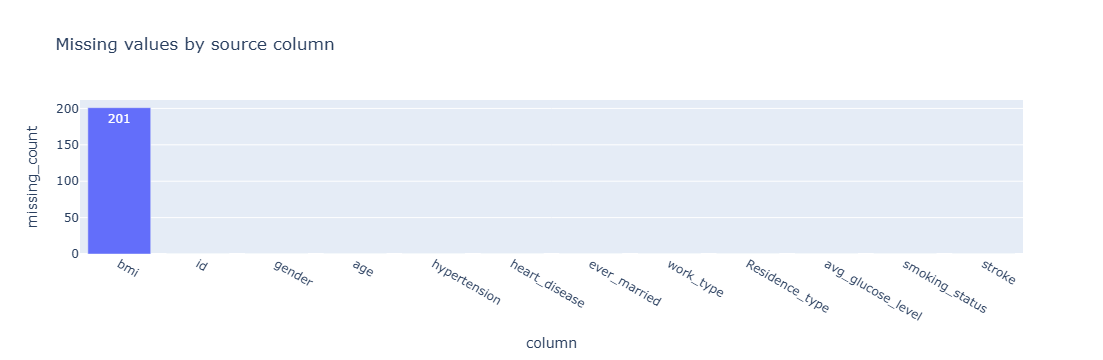

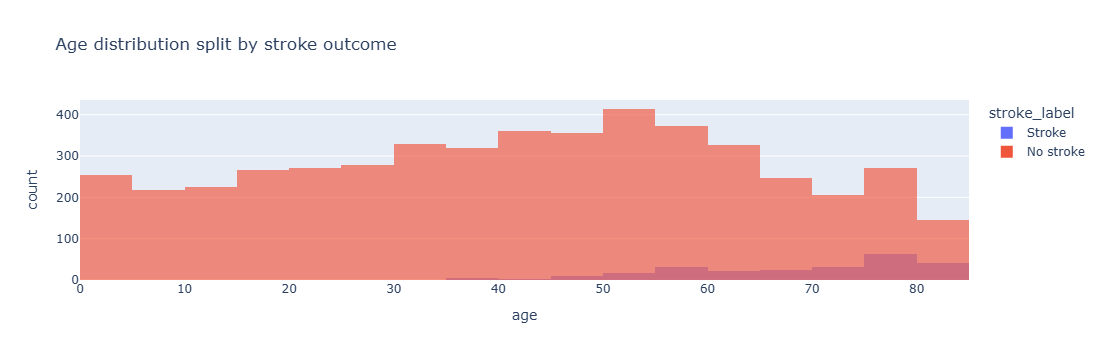

In [25]:
# Load the source dataset once and keep the raw frame intact for audit.
df_raw = pd.read_csv(DATA_PATH)
display(df_raw.head())

summary = pd.DataFrame(
    {
        "metric": ["rows", "columns", "positive_cases", "negative_cases", "positive_rate"],
        "value": [len(df_raw), df_raw.shape[1], int(df_raw[TARGET_COLUMN].sum()), int((df_raw[TARGET_COLUMN] == 0).sum()), float(df_raw[TARGET_COLUMN].mean())],
    }
)
display(summary)

missing_summary = (
    df_raw.replace("N/A", np.nan)
    .isna()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_summary["missing_pct"] = missing_summary["missing_count"] / len(df_raw)
display(missing_summary.sort_values("missing_count", ascending=False))

class_counts = df_raw[TARGET_COLUMN].value_counts().rename_axis("stroke").reset_index(name="count")
class_counts["stroke_label"] = class_counts["stroke"].map({0: "No stroke", 1: "Stroke"})
fig_class = px.bar(class_counts, x="stroke_label", y="count", color="stroke_label", text="count", title="Class imbalance in the dataset")
fig_class.update_layout(showlegend=False)
fig_class.show()

fig_missing = px.bar(missing_summary.sort_values("missing_count", ascending=False), x="column", y="missing_count", text="missing_count", title="Missing values by source column")
fig_missing.show()

age_plot_df = df_raw.copy()
age_plot_df["stroke_label"] = age_plot_df[TARGET_COLUMN].map({0: "No stroke", 1: "Stroke"})
fig_age = px.histogram(age_plot_df, x="age", color="stroke_label", nbins=30, barmode="overlay", opacity=0.65, title="Age distribution split by stroke outcome")
fig_age.show()

The target distribution is heavily imbalanced, so raw accuracy would be misleading on its own. That is why recall remains the primary decision metric in the rest of the notebook: a screening model should miss as few at-risk cases as practical, even if that means accepting more false positives.

## Preprocessing

The notebook keeps preprocessing explicit and close to the analysis so each decision is easy to review. The same high-level rules should later be reflected in the production preprocessing module.

Key choices in this notebook:
- the dataset is split into `train`, `validation`, and untouched `test` partitions
- `id` is dropped because it is an identifier, not a clinical signal
- `bmi` uses training-median imputation
- `age` stays continuous instead of being grouped
- `gender_other` is retained explicitly
- smoking is encoded with the same selected indicators used by the project
- continuous fields are scaled for the linear baseline

The comments in the code cell below explain each preprocessing step line by line.

In [29]:
# Step 1: prepare the modelling dataframe.
# Replace text placeholders for missing values and drop the identifier column.
df_model = df_raw.copy().replace("N/A", np.nan).drop(columns=["id"])
X_raw = df_model.drop(columns=[TARGET_COLUMN])
y = df_model[TARGET_COLUMN].copy()

# Step 2: create the untouched holdout test split first.
# From this point on, the test split must not influence model choice, parameter
# tuning, or threshold selection.
X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Step 3: split the remaining development data into train and validation.
# Training learns preprocessing state and model weights.
# Validation is used for model comparison, threshold choice, and tuning.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw,
    y_trainval,
    test_size=VALIDATION_SIZE_WITHIN_TRAINVAL,
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train_raw), len(X_val_raw), len(X_test_raw)],
    "positive_rate": [float(y_train.mean()), float(y_val.mean()), float(y_test.mean())],
}))


def normalize_inputs(df: pd.DataFrame) -> pd.DataFrame:
    """Clean raw string categories so one-hot encoding stays consistent."""
    df = df.copy()
    df["gender"] = df["gender"].apply(lambda value: value if pd.isna(value) else str(value).strip().title())
    smoking_map = {
        "never smoked": "never smoked",
        "formerly smoked": "formerly smoked",
        "smokes": "smokes",
        "unknown": "Unknown",
    }
    df["smoking_status"] = df["smoking_status"].apply(
        lambda value: value if pd.isna(value) else smoking_map.get(str(value).strip().lower(), str(value).strip())
    )
    return df


def engineer_features(df: pd.DataFrame, bmi_median: float) -> pd.DataFrame:
    """Convert raw input columns into the fixed model feature schema."""
    df = normalize_inputs(df)
    engineered = pd.DataFrame(index=df.index)

    # Keep the continuous numeric signals directly.
    engineered["age"] = pd.to_numeric(df["age"], errors="coerce")
    engineered["hypertension"] = pd.to_numeric(df["hypertension"], errors="coerce").fillna(0).astype(int)
    engineered["heart_disease"] = pd.to_numeric(df["heart_disease"], errors="coerce").fillna(0).astype(int)
    engineered["avg_glucose_level"] = pd.to_numeric(df["avg_glucose_level"], errors="coerce")

    # Fill missing BMI with the median learned from training only.
    engineered["bmi"] = pd.to_numeric(df["bmi"], errors="coerce").fillna(bmi_median)

    # Build one-hot indicators, then keep only the columns used by the model.
    gender_dummies = pd.get_dummies(df["gender"], prefix="gender")
    smoking_dummies = pd.get_dummies(df["smoking_status"], prefix="smoking_status")

    engineered["gender_other"] = gender_dummies.get("gender_Other", pd.Series(0, index=df.index))
    engineered["smoking_status_formerly smoked"] = smoking_dummies.get("smoking_status_formerly smoked", pd.Series(0, index=df.index))
    engineered["smoking_status_smokes"] = smoking_dummies.get("smoking_status_smokes", pd.Series(0, index=df.index))
    engineered["smoking_status_Unknown"] = smoking_dummies.get("smoking_status_Unknown", pd.Series(0, index=df.index))

    # Reindex to the frozen feature order so training and inference stay aligned.
    return engineered.reindex(columns=SELECTED_FEATURES, fill_value=0)


def fit_preprocessor(train_df: pd.DataFrame):
    """Learn imputation and scaling state from the training split only."""
    bmi_non_null = pd.to_numeric(train_df["bmi"], errors="coerce").dropna()
    if bmi_non_null.empty:
        raise ValueError("Training split cannot learn BMI median because all BMI values are missing.")

    bmi_median = float(bmi_non_null.median())
    scaler = StandardScaler()
    train_features = engineer_features(train_df, bmi_median)

    # Only continuous variables are scaled. Binary indicators stay as 0/1.
    scaler.fit(train_features[SCALED_FEATURES])
    return bmi_median, scaler


def transform_with_preprocessor(df: pd.DataFrame, bmi_median: float, scaler: StandardScaler):
    """Return a tree-ready matrix and a scaled linear-model matrix."""
    tree_features = engineer_features(df, bmi_median).copy()
    linear_features = tree_features.copy()
    linear_features[SCALED_FEATURES] = scaler.transform(linear_features[SCALED_FEATURES])
    return tree_features, linear_features


# Learn preprocessing state from train only, then reuse it for validation/test.
bmi_median, scaler = fit_preprocessor(X_train_raw)
X_train_tree, X_train_linear = transform_with_preprocessor(X_train_raw, bmi_median, scaler)
X_val_tree, X_val_linear = transform_with_preprocessor(X_val_raw, bmi_median, scaler)
X_test_tree, X_test_linear = transform_with_preprocessor(X_test_raw, bmi_median, scaler)

display(pd.concat([X_train_raw.head(1).reset_index(drop=True), X_train_tree.head(1).reset_index(drop=True)], axis=1))
display(Markdown(f"**Training BMI median used for imputation:** `{bmi_median:0.2f}`"))
display(Markdown("**Continuous features scaled for the linear baseline:** `age`, `avg_glucose_level`, `bmi`"))

,split,rows,positive_rate
0,train,3066,0.0486
1,validation,1022,0.0489
2,test,1022,0.0489


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_other,smoking_status_formerly smoked,smoking_status_smokes,smoking_status_Unknown
0,Male,2.0000,0,0,No,children,Urban,112.9200,18.4000,Unknown,2.0000,0,0,112.9200,18.4000,False,False,False,True


**Training BMI median used for imputation:** `28.10`

**Continuous features scaled for the linear baseline:** `age`, `avg_glucose_level`, `bmi`

## Model Comparison

The four candidate models come directly from the current training module. This keeps the notebook aligned with the codebase while still allowing the analysis to remain explicit.

- **Logistic Regression**: interpretable linear baseline.
- **Balanced Random Forest**: strong recall candidate for imbalanced data.
- **Random Forest**: standard tree ensemble baseline.
- **Gradient Boosting**: useful contrast for a more accuracy-oriented boosting approach.

All ranking decisions in this section are made on the validation split. The test split remains untouched.

The four models above remain the current baseline portfolio because they match the production training module. The next section adds **XGBoost** as a notebook-only challenger so a stronger boosted-tree option can be tested without changing the reusable training code yet.

Alongside recall, the notebook now reports:
- **F1**: equal balance between precision and recall
- **F2**: recall-weighted balance, which is commonly used when recall matters more than precision
- **Average Precision (AP)**: threshold-free summary of the precision-recall curve

C:\Users\rkrb1\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning:

The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.

C:\Users\rkrb1\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning:

The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.

C:\Users\rkrb1\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning:

The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.



,model_label,accuracy,precision,recall,f1_score,f2_score,roc_auc,average_precision,threshold
1,Balanced Random Forest,0.5714,0.1008,0.9800,0.1828,0.3571,0.8530,0.2098,0.3000
2,Random Forest,0.6252,0.1101,0.9400,0.1971,0.3748,0.8330,0.1964,0.3000
0,Logistic Regression,0.5930,0.1004,0.9200,0.1811,0.3495,0.8407,0.1705,0.3000
3,Gradient Boosting,0.9403,0.2609,0.1200,0.1644,0.1345,0.8458,0.1798,0.3000


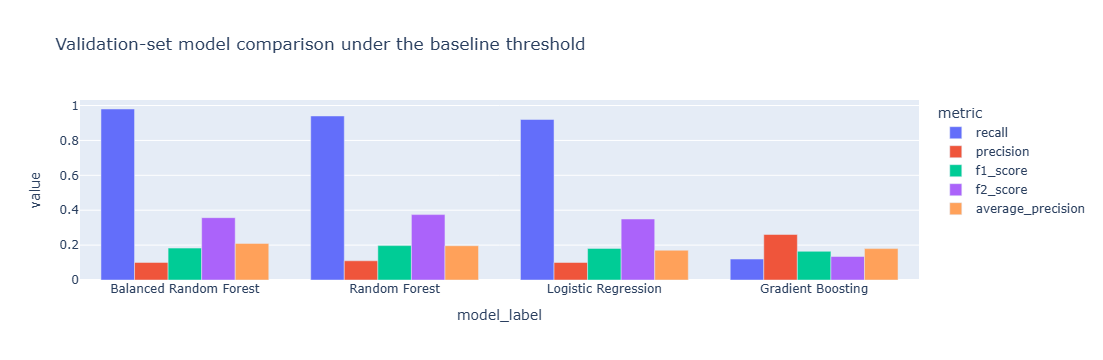

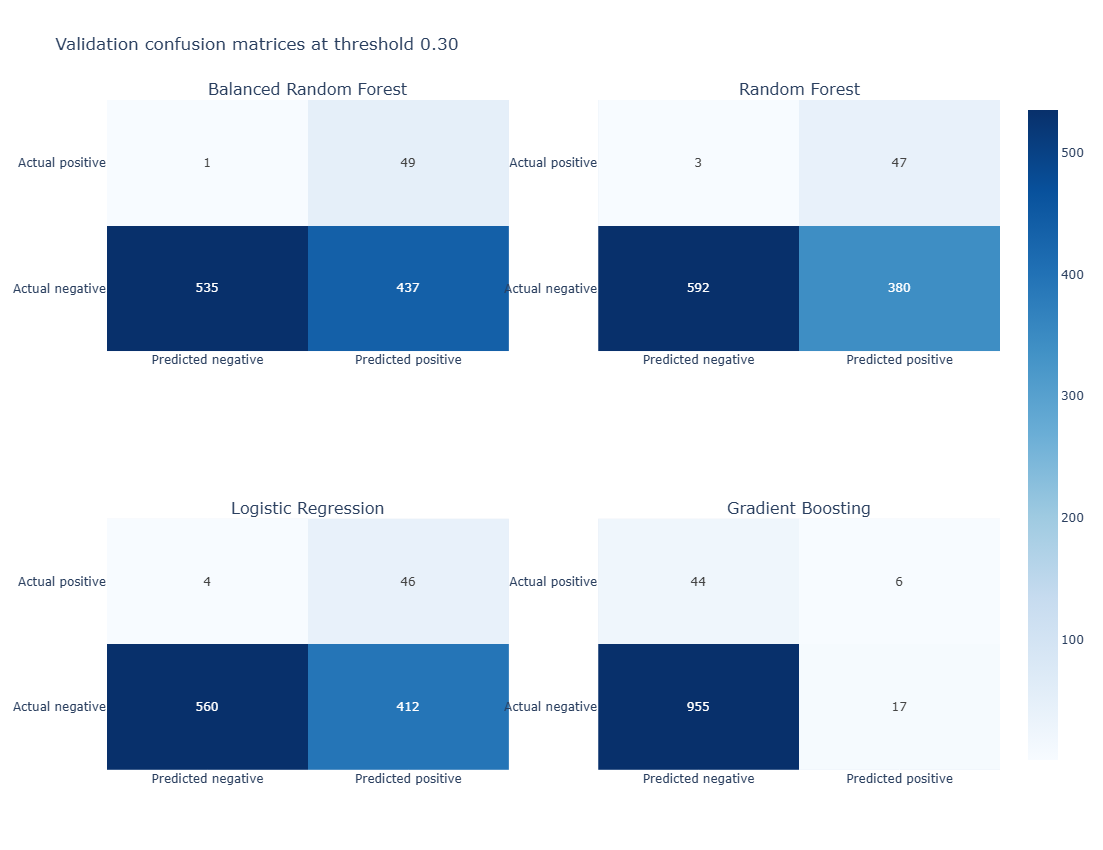

In [32]:
# This block defines reusable evaluation helpers.
# Keeping metric logic in one place makes every model comparison consistent.
def apply_threshold(probabilities: np.ndarray, threshold: float = SCREENING_THRESHOLD) -> np.ndarray:
    """Convert predicted probabilities into class predictions."""
    return (probabilities >= threshold).astype(int)


def compute_metrics(y_true, probabilities, threshold: float = SCREENING_THRESHOLD):
    """Calculate threshold-based and threshold-free metrics together."""
    predictions = apply_threshold(probabilities, threshold)
    matrix = confusion_matrix(y_true, predictions)
    tn, fp, fn, tp = matrix.ravel()

    metrics = {
        "accuracy": float((predictions == y_true).mean()),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "f1_score": float(f1_score(y_true, predictions, zero_division=0)),
        "f2_score": float(fbeta_score(y_true, predictions, beta=2, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "average_precision": float(average_precision_score(y_true, probabilities)),
        "confusion_matrix": matrix,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold),
    }
    return metrics


def evaluate_model(model, X_train, X_eval, y_train, y_eval, threshold: float = SCREENING_THRESHOLD):
    """Fit once on training data and evaluate once on validation/test data."""
    model.fit(X_train, y_train)
    probabilities = model.predict_proba(X_eval)[:, 1]
    metrics = compute_metrics(y_eval, probabilities, threshold)
    return metrics, model, probabilities


baseline_results = []
fitted_models = {}
validation_probabilities = {}

for model_key, model_config in MODEL_REGISTRY.items():
    model = model_config["factory"]()
    X_train_current = X_train_linear if model_config["uses_scaled_features"] else X_train_tree
    X_eval_current = X_val_linear if model_config["uses_scaled_features"] else X_val_tree

    metrics, fitted_model, probabilities = evaluate_model(
        model,
        X_train_current,
        X_eval_current,
        y_train,
        y_val,
    )

    fitted_models[model_key] = fitted_model
    validation_probabilities[model_key] = probabilities
    baseline_results.append({
        "model_key": model_key,
        "model_label": model_config["label"],
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "f2_score": metrics["f2_score"],
        "roc_auc": metrics["roc_auc"],
        "average_precision": metrics["average_precision"],
        "threshold": metrics["threshold"],
        "confusion_matrix": metrics["confusion_matrix"],
    })

# Sort recall-first, but keep recall-weighted F2 in the ranking signal.
comparison_df = pd.DataFrame(baseline_results).sort_values(
    ["recall", "f2_score", "average_precision", "precision"],
    ascending=[False, False, False, False],
)
display(comparison_df[["model_label", "accuracy", "precision", "recall", "f1_score", "f2_score", "roc_auc", "average_precision", "threshold"]])

comparison_melted = comparison_df.melt(
    id_vars=["model_label"],
    value_vars=["recall", "precision", "f1_score", "f2_score", "average_precision"],
    var_name="metric",
    value_name="value",
)
fig_metrics = px.bar(
    comparison_melted,
    x="model_label",
    y="value",
    color="metric",
    barmode="group",
    title="Validation-set model comparison under the baseline threshold",
)
fig_metrics.show()

subplot_titles = list(comparison_df["model_label"])
fig_conf = make_subplots(rows=2, cols=2, subplot_titles=subplot_titles)
for idx, (_, row) in enumerate(comparison_df.iterrows(), start=1):
    fig_conf.add_trace(
        go.Heatmap(
            z=row["confusion_matrix"],
            x=["Predicted negative", "Predicted positive"],
            y=["Actual negative", "Actual positive"],
            text=row["confusion_matrix"],
            texttemplate="%{text}",
            colorscale="Blues",
            showscale=(idx == 1),
        ),
        row=(idx - 1) // 2 + 1,
        col=(idx - 1) % 2 + 1,
    )
fig_conf.update_layout(height=850, title_text="Validation confusion matrices at threshold 0.30")
fig_conf.show()

## XGBoost Candidate

This section adds **XGBoost** as a notebook-only challenger inside the existing experiment flow.
The original four models remain the current baseline portfolio because they mirror the reusable training module.

The goal here is different from the earlier baseline comparison:
- keep the same preprocessing and validation discipline
- test whether a stronger boosted-tree learner is worth promoting later
- document the major XGBoost parameters in plain language before treating tuning as a black-box exercise
- keep the holdout test untouched


### Why XGBoost Is Worth Testing

XGBoost is a common company-grade tabular-data benchmark because it often captures nonlinear relationships more effectively than older boosting implementations while still giving disciplined control over regularisation.

Why it fits this notebook:
- it is strong on small-to-medium structured datasets
- it lets the notebook weight rare stroke cases more explicitly through `scale_pos_weight`
- early stopping helps automate tuning without blindly forcing every boosting round to run
- it is a realistic next challenger if the project later expands beyond the current four-model baseline

Why it needs more explanation than logistic regression:
- more parameters control learning behaviour, overfitting risk, and class imbalance
- feature importance is only a global signal, not a patient-level explanation
- threshold choice still matters after tuning because the fitted model outputs probabilities rather than final screening decisions


In [ ]:
# XGBoost stays notebook-only for now so the production model registry remains unchanged.
if XGBClassifier is None:
    raise ImportError(
        "XGBoost is not installed in this notebook environment. "
        "Install `xgboost` in the active kernel, then rerun this section."
    )


def compute_scale_pos_weight(y: pd.Series) -> float:
    # Approximate the class imbalance ratio for XGBoost positive-class weighting.
    positive_cases = int(y.sum())
    negative_cases = int((y == 0).sum())
    if positive_cases == 0:
        raise ValueError("scale_pos_weight cannot be computed because the training split has no positive cases.")
    return negative_cases / positive_cases


def fit_xgb_candidate(params: dict, X_train: pd.DataFrame, y_train: pd.Series, X_eval: pd.DataFrame, y_eval: pd.Series):
    # Fit one XGBoost candidate with early stopping, then return validation metrics.
    model = XGBClassifier(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_eval, y_eval)],
        verbose=False,
    )
    probabilities = model.predict_proba(X_eval)[:, 1]
    metrics = compute_metrics(y_eval, probabilities, threshold=SCREENING_THRESHOLD)
    return model, probabilities, metrics


xgb_class_ratio = compute_scale_pos_weight(y_train)

xgb_baseline_params = {
    # Predict probabilities for a binary screening task instead of hard labels.
    "objective": "binary:logistic",
    # Align early stopping with the precision-recall focus used later in ranking.
    "eval_metric": "aucpr",
    # Learn in smaller steps so boosting is less likely to overreact to one split.
    "learning_rate": 0.05,
    # Allow enough boosting rounds for learning, then let early stopping cut it short.
    "n_estimators": 600,
    # Keep baseline trees shallow so the first run stays conservative and interpretable.
    "max_depth": 3,
    # Require enough weighted observations in a node before another split is allowed.
    "min_child_weight": 5,
    # Start with no extra minimum-gain barrier; later tuning can make splitting stricter.
    "gamma": 0.0,
    # Sample most rows for each tree to reduce overfitting without starving the model.
    "subsample": 0.9,
    # Sample most columns for each tree for the same reason on the feature side.
    "colsample_bytree": 0.9,
    # Leave L1 regularisation off in the baseline so sparsity is not forced too early.
    "reg_alpha": 0.0,
    # Keep a light L2 penalty so leaf weights stay stable on a small dataset.
    "reg_lambda": 1.0,
    # Reweight the rare positive class so recall does not collapse toward the majority class.
    "scale_pos_weight": xgb_class_ratio,
    # Use histogram tree building because it is faster for repeated notebook experiments.
    "tree_method": "hist",
    # Fix randomness so the baseline is reproducible.
    "random_state": RANDOM_STATE,
    # Use all available CPU cores in the notebook kernel.
    "n_jobs": -1,
    # Stop when validation AUCPR plateaus instead of forcing every round to finish.
    "early_stopping_rounds": 30,
}

xgb_baseline_model, xgb_baseline_probabilities, xgb_baseline_metrics = fit_xgb_candidate(
    xgb_baseline_params,
    X_train_tree,
    y_train,
    X_val_tree,
    y_val,
)

xgb_baseline_summary_df = pd.DataFrame([
    {
        "model_label": "XGBoost (baseline)",
        "accuracy": xgb_baseline_metrics["accuracy"],
        "precision": xgb_baseline_metrics["precision"],
        "recall": xgb_baseline_metrics["recall"],
        "f1_score": xgb_baseline_metrics["f1_score"],
        "f2_score": xgb_baseline_metrics["f2_score"],
        "roc_auc": xgb_baseline_metrics["roc_auc"],
        "average_precision": xgb_baseline_metrics["average_precision"],
        "threshold": xgb_baseline_metrics["threshold"],
        "fp": xgb_baseline_metrics["fp"],
        "fn": xgb_baseline_metrics["fn"],
    }
])
display(xgb_baseline_summary_df)

xgb_tree_baseline_compare_df = pd.concat(
    [
        comparison_df[comparison_df["model_key"].isin(["balanced_rf", "random_forest", "gradient_boosting"])][
            ["model_label", "precision", "recall", "f1_score", "f2_score", "roc_auc", "average_precision"]
        ],
        xgb_baseline_summary_df[["model_label", "precision", "recall", "f1_score", "f2_score", "roc_auc", "average_precision"]],
    ],
    ignore_index=True,
)
display(xgb_tree_baseline_compare_df.sort_values(["average_precision", "f2_score", "recall"], ascending=[False, False, False]))

fig_xgb_baseline = px.bar(
    xgb_tree_baseline_compare_df.melt(
        id_vars=["model_label"],
        value_vars=["recall", "f2_score", "average_precision"],
        var_name="metric",
        value_name="value",
    ),
    x="model_label",
    y="value",
    color="metric",
    barmode="group",
    title="Baseline XGBoost versus the current tree-model baselines",
)
fig_xgb_baseline.show()


### XGBoost Parameter Guide

The table below is deliberately broader than the tuning grid. The point is to explain the major knobs before automating them.

Read it in three layers:
- **what it changes**: the part of training or model shape the parameter controls
- **why it matters here**: why that control affects an imbalanced stroke-screening dataset
- **risk if pushed too far**: the most likely failure mode when the value is too low or too high

Not every parameter needs to be tuned in every project. In this notebook, some remain fixed so the staged search stays readable.


In [ ]:
xgb_parameter_guide_df = pd.DataFrame([
    {
        "parameter": "learning_rate",
        "role": "learning dynamics",
        "what_it_changes": "Shrinks how much each boosted tree can move the model.",
        "why_it_matters_here": "Lower values usually generalise better on a small clinical-style tabular dataset.",
        "risk_if_too_low": "Training can become slow or underfit unless many trees are added.",
        "risk_if_too_high": "The model can chase noisy validation patterns and overfit quickly.",
        "notebook_use": "Tuned in Stage 2.",
    },
    {
        "parameter": "n_estimators",
        "role": "learning dynamics",
        "what_it_changes": "Maximum number of boosting rounds available to the model.",
        "why_it_matters_here": "Works with early stopping so the notebook can automate model length instead of guessing it.",
        "risk_if_too_low": "The model may stop before learning enough minority-class structure.",
        "risk_if_too_high": "Training cost rises, though early stopping usually limits the practical impact.",
        "notebook_use": "Fixed high and governed by early stopping.",
    },
    {
        "parameter": "max_depth",
        "role": "tree size",
        "what_it_changes": "Maximum depth each tree can reach.",
        "why_it_matters_here": "Deeper trees capture interactions but can memorize a small dataset.",
        "risk_if_too_low": "The model behaves too simply and misses useful nonlinear effects.",
        "risk_if_too_high": "Recall may look good on validation by fitting noise that will not hold up.",
        "notebook_use": "Tuned in Stage 2.",
    },
    {
        "parameter": "min_child_weight",
        "role": "tree size",
        "what_it_changes": "How much weighted data a node needs before another split is allowed.",
        "why_it_matters_here": "Stops the model from building branches around tiny rare patterns that may be unstable.",
        "risk_if_too_low": "Very small leaves can make the model fragile.",
        "risk_if_too_high": "Useful minority-class splits may never happen.",
        "notebook_use": "Tuned in Stage 2.",
    },
    {
        "parameter": "gamma",
        "role": "split gating",
        "what_it_changes": "Minimum gain required before XGBoost accepts a new split.",
        "why_it_matters_here": "Adds an explicit brake when the model starts making low-value branches.",
        "risk_if_too_low": "The model can grow noisy extra structure.",
        "risk_if_too_high": "The model may refuse genuinely useful splits.",
        "notebook_use": "Tuned in Stage 3.",
    },
    {
        "parameter": "subsample",
        "role": "row sampling",
        "what_it_changes": "Fraction of training rows sampled per tree.",
        "why_it_matters_here": "Reduces correlation between trees and can improve robustness.",
        "risk_if_too_low": "Each tree sees too little signal.",
        "risk_if_too_high": "Trees become more similar and overfitting risk rises.",
        "notebook_use": "Tuned in Stage 3.",
    },
    {
        "parameter": "colsample_bytree",
        "role": "column sampling",
        "what_it_changes": "Fraction of features sampled per tree.",
        "why_it_matters_here": "Helps when a few strong features like age or glucose dominate every tree.",
        "risk_if_too_low": "Important features may be hidden too often.",
        "risk_if_too_high": "Trees rely too heavily on the same top predictors.",
        "notebook_use": "Tuned in Stage 3.",
    },
    {
        "parameter": "reg_alpha",
        "role": "regularisation",
        "what_it_changes": "L1 penalty that can shrink some leaf weights toward zero.",
        "why_it_matters_here": "Useful when the model starts reacting too strongly to sparse patterns.",
        "risk_if_too_low": "The model may remain noisier than necessary.",
        "risk_if_too_high": "The model can become too hesitant and lose useful signal.",
        "notebook_use": "Tuned in Stage 3.",
    },
    {
        "parameter": "reg_lambda",
        "role": "regularisation",
        "what_it_changes": "L2 penalty that smooths leaf weights rather than zeroing them out.",
        "why_it_matters_here": "Often stabilises boosting without making it too sparse.",
        "risk_if_too_low": "Leaf weights can become too reactive.",
        "risk_if_too_high": "Predicted probabilities can flatten and underfit.",
        "notebook_use": "Tuned in Stage 3.",
    },
    {
        "parameter": "scale_pos_weight",
        "role": "imbalance handling",
        "what_it_changes": "Relative weight applied to the positive stroke class during training.",
        "why_it_matters_here": "The dataset is highly imbalanced, so unweighted boosting may ignore rare positives.",
        "risk_if_too_low": "Recall can collapse toward the majority class.",
        "risk_if_too_high": "False positives can explode because the model over-prioritises rare cases.",
        "notebook_use": "Tuned in Stage 4 around the empirical class ratio.",
    },
    {
        "parameter": "objective",
        "role": "run behavior",
        "what_it_changes": "Defines the optimisation target and output shape.",
        "why_it_matters_here": "Binary logistic output is appropriate because later thresholding needs probabilities.",
        "risk_if_too_low": "Not applicable; this is a categorical choice, not a numeric scale.",
        "risk_if_too_high": "Not applicable; the main risk is choosing the wrong objective entirely.",
        "notebook_use": "Fixed to binary:logistic.",
    },
    {
        "parameter": "eval_metric",
        "role": "run behavior",
        "what_it_changes": "Metric monitored during training and early stopping.",
        "why_it_matters_here": "AUCPR is more informative than accuracy for rare-event ranking quality.",
        "risk_if_too_low": "Not applicable; the main risk is monitoring an irrelevant metric.",
        "risk_if_too_high": "Not applicable; the choice itself matters more than scale.",
        "notebook_use": "Fixed to aucpr.",
    },
    {
        "parameter": "random_state / n_jobs",
        "role": "run behavior",
        "what_it_changes": "Reproducibility and training parallelism.",
        "why_it_matters_here": "The notebook should be reproducible and still finish in reasonable time.",
        "risk_if_too_low": "Not applicable; missing control harms reproducibility more than quality.",
        "risk_if_too_high": "Using too many resources can make notebook sharing harder on small machines.",
        "notebook_use": "Fixed for reproducibility and speed.",
    },
])
display(xgb_parameter_guide_df)


### Automated Tuning Strategy

"Best tuning can be automated" does **not** mean letting a giant blind grid run forever. In a company setting, the cleaner approach is usually staged:

1. start from a defensible baseline
2. tune the parameters that control model capacity first
3. tune sampling and regularisation second
4. tune imbalance weighting after the model shape is stable
5. pick the decision threshold only after the fitted probability model is chosen

This notebook uses that staged pattern on purpose. The ranking rule for **hyperparameter** tuning is:
- highest **Average Precision (AP / PR-AUC)**
- then highest **F2**
- then highest **recall**
- then highest **precision**

Threshold selection is kept separate afterwards because AP does not change with the threshold.


In [ ]:
def xgb_rank_key(metrics: dict) -> tuple:
    # Rank fitted candidates by threshold-free quality first, then recall-sensitive thresholded quality.
    return (
        metrics["average_precision"],
        metrics["f2_score"],
        metrics["recall"],
        metrics["precision"],
    )


xgb_stage_searches = [
    {
        "stage": "Stage 2 - complexity",
        "grid": {
            "learning_rate": [0.03, 0.05],
            "max_depth": [2, 3, 4],
            "min_child_weight": [3, 5],
        },
    },
    {
        "stage": "Stage 3 - sampling and regularisation",
        "grid": {
            "subsample": [0.8, 0.9],
            "colsample_bytree": [0.8, 0.9],
            "gamma": [0.0, 0.5],
            "reg_alpha": [0.0, 0.2],
            "reg_lambda": [1.0],
        },
    },
    {
        "stage": "Stage 4 - class weighting",
        "grid": {
            "scale_pos_weight": [
                round(xgb_class_ratio * 0.75, 4),
                round(xgb_class_ratio, 4),
                round(xgb_class_ratio * 1.25, 4),
            ],
        },
    },
]

xgb_current_best_params = xgb_baseline_params.copy()
xgb_current_best_model = xgb_baseline_model
xgb_current_best_probabilities = xgb_baseline_probabilities
xgb_current_best_metrics = xgb_baseline_metrics.copy()

xgb_stage_rows = []

for stage_config in xgb_stage_searches:
    stage_best = None

    for overrides in ParameterGrid(stage_config["grid"]):
        candidate_params = xgb_current_best_params.copy()
        candidate_params.update(overrides)

        candidate_model, candidate_probabilities, candidate_metrics = fit_xgb_candidate(
            candidate_params,
            X_train_tree,
            y_train,
            X_val_tree,
            y_val,
        )

        candidate_row = {
            "stage": stage_config["stage"],
            "tested_overrides": overrides,
            "validation_precision": candidate_metrics["precision"],
            "validation_recall": candidate_metrics["recall"],
            "validation_f1": candidate_metrics["f1_score"],
            "validation_f2": candidate_metrics["f2_score"],
            "validation_roc_auc": candidate_metrics["roc_auc"],
            "validation_average_precision": candidate_metrics["average_precision"],
        }

        if stage_best is None or xgb_rank_key(candidate_metrics) > xgb_rank_key(stage_best["metrics"]):
            stage_best = {
                "params": candidate_params,
                "overrides": overrides,
                "model": candidate_model,
                "probabilities": candidate_probabilities,
                "metrics": candidate_metrics,
                "row": candidate_row,
            }

    xgb_current_best_params = stage_best["params"]
    xgb_current_best_model = stage_best["model"]
    xgb_current_best_probabilities = stage_best["probabilities"]
    xgb_current_best_metrics = stage_best["metrics"]
    xgb_stage_rows.append(stage_best["row"])

xgb_stage_summary_df = pd.DataFrame(xgb_stage_rows)
display(xgb_stage_summary_df)

xgb_tuned_model = xgb_current_best_model
xgb_tuned_probabilities = xgb_current_best_probabilities
xgb_tuned_metrics = xgb_current_best_metrics
xgb_tuned_params = xgb_current_best_params.copy()

display(Markdown(
    "**Best tuned XGBoost parameter set:** "
    f"`{xgb_tuned_params}`"
))


In [ ]:
xgb_before_after_df = pd.DataFrame([
    {
        "stage": "baseline",
        "precision": xgb_baseline_metrics["precision"],
        "recall": xgb_baseline_metrics["recall"],
        "f1_score": xgb_baseline_metrics["f1_score"],
        "f2_score": xgb_baseline_metrics["f2_score"],
        "roc_auc": xgb_baseline_metrics["roc_auc"],
        "average_precision": xgb_baseline_metrics["average_precision"],
        "fp": xgb_baseline_metrics["fp"],
        "fn": xgb_baseline_metrics["fn"],
    },
    {
        "stage": "tuned",
        "precision": xgb_tuned_metrics["precision"],
        "recall": xgb_tuned_metrics["recall"],
        "f1_score": xgb_tuned_metrics["f1_score"],
        "f2_score": xgb_tuned_metrics["f2_score"],
        "roc_auc": xgb_tuned_metrics["roc_auc"],
        "average_precision": xgb_tuned_metrics["average_precision"],
        "fp": xgb_tuned_metrics["fp"],
        "fn": xgb_tuned_metrics["fn"],
    },
])
display(xgb_before_after_df)

xgb_vs_tree_df = pd.concat(
    [
        comparison_df[comparison_df["model_key"].isin(["balanced_rf", "random_forest", "gradient_boosting"])][
            ["model_label", "precision", "recall", "f1_score", "f2_score", "roc_auc", "average_precision"]
        ],
        pd.DataFrame([
            {
                "model_label": "XGBoost (tuned)",
                "precision": xgb_tuned_metrics["precision"],
                "recall": xgb_tuned_metrics["recall"],
                "f1_score": xgb_tuned_metrics["f1_score"],
                "f2_score": xgb_tuned_metrics["f2_score"],
                "roc_auc": xgb_tuned_metrics["roc_auc"],
                "average_precision": xgb_tuned_metrics["average_precision"],
            }
        ]),
    ],
    ignore_index=True,
)
display(xgb_vs_tree_df.sort_values(["average_precision", "f2_score", "recall"], ascending=[False, False, False]))

fig_xgb_tuned = px.bar(
    xgb_vs_tree_df.melt(
        id_vars=["model_label"],
        value_vars=["recall", "f2_score", "average_precision"],
        var_name="metric",
        value_name="value",
    ),
    x="model_label",
    y="value",
    color="metric",
    barmode="group",
    title="Tuned XGBoost versus the current tree-model baselines",
)
fig_xgb_tuned.show()

best_existing_tree = xgb_vs_tree_df[xgb_vs_tree_df["model_label"] != "XGBoost (tuned)"].sort_values(
    ["average_precision", "f2_score", "recall"],
    ascending=[False, False, False],
).iloc[0]

if (
    xgb_tuned_metrics["average_precision"] > float(best_existing_tree["average_precision"])
    and xgb_tuned_metrics["f2_score"] >= float(best_existing_tree["f2_score"])
):
    xgb_conclusion = (
        "Tuned XGBoost is a stronger challenger than the current tree baselines on validation because it improves "
        "ranking quality without giving back recall-weighted screening performance."
    )
elif xgb_tuned_metrics["average_precision"] > float(best_existing_tree["average_precision"]):
    xgb_conclusion = (
        "Tuned XGBoost improves threshold-free ranking quality, but it still needs a threshold decision review because "
        "its recall-sensitive tradeoff is not clearly dominant."
    )
else:
    xgb_conclusion = (
        "Tuned XGBoost is a credible challenger, but the current tree baselines remain more convincing for this notebook's "
        "recall-sensitive objective."
    )

display(Markdown(
    "### XGBoost Challenger Summary\n"
    f"- Best existing tree benchmark in this notebook: **{best_existing_tree['model_label']}**.\n"
    f"- Validation conclusion: {xgb_conclusion}"
))


In [ ]:
xgb_threshold_rows = []

for threshold in THRESHOLD_GRID:
    metrics = compute_metrics(y_val, xgb_tuned_probabilities, threshold=float(threshold))
    xgb_threshold_rows.append(
        {
            "threshold": float(threshold),
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1_score"],
            "f2_score": metrics["f2_score"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
            "tn": metrics["tn"],
            "confusion_matrix": metrics["confusion_matrix"],
        }
    )

xgb_threshold_df = pd.DataFrame(xgb_threshold_rows)
display(xgb_threshold_df[["threshold", "precision", "recall", "f1_score", "f2_score", "fp", "fn"]])

xgb_recommended_threshold = xgb_threshold_df.sort_values(
    ["f2_score", "recall", "precision", "threshold"],
    ascending=[False, False, False, True],
).iloc[0]
display(pd.DataFrame([xgb_recommended_threshold[["threshold", "precision", "recall", "f1_score", "f2_score", "fp", "fn"]]]))

xgb_threshold_plot_df = xgb_threshold_df.melt(
    id_vars=["threshold"],
    value_vars=["precision", "recall", "f1_score", "f2_score"],
    var_name="metric",
    value_name="value",
)
fig_xgb_thresholds = px.line(
    xgb_threshold_plot_df,
    x="threshold",
    y="value",
    color="metric",
    markers=True,
    title="Tuned XGBoost validation metrics across threshold choices",
)
fig_xgb_thresholds.show()

baseline_xgb_matrix = xgb_threshold_df.loc[
    xgb_threshold_df["threshold"] == SCREENING_THRESHOLD,
    "confusion_matrix",
].iloc[0]
selected_xgb_matrix = xgb_recommended_threshold["confusion_matrix"]

fig_xgb_conf = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        f"Tuned XGBoost @ {SCREENING_THRESHOLD:0.2f}",
        f"Tuned XGBoost @ {float(xgb_recommended_threshold['threshold']):0.2f}",
    ],
)
for idx, matrix in enumerate([baseline_xgb_matrix, selected_xgb_matrix], start=1):
    fig_xgb_conf.add_trace(
        go.Heatmap(
            z=matrix,
            x=["Predicted negative", "Predicted positive"],
            y=["Actual negative", "Actual positive"],
            text=matrix,
            texttemplate="%{text}",
            colorscale="Greens",
            showscale=(idx == 1),
        ),
        row=1,
        col=idx,
    )
fig_xgb_conf.update_layout(height=450, title_text="Tuned XGBoost baseline threshold versus selected threshold")
fig_xgb_conf.show()

display(Markdown(
    "**Threshold note:** threshold search happens after model tuning because AP stays constant across thresholds. "
    "This section therefore uses validation `F2`, recall, and precision to choose an operating point for the already-fitted XGBoost model."
))


## Threshold Analysis

Thresholding matters because the same probability model can behave very differently depending on where the decision cutoff is placed.

This section is exploratory:
- use the **validation** split only
- inspect **precision-recall curves**
- inspect **threshold-versus-metric** charts
- understand how nearby thresholds trade recall against precision

The notebook does **not** treat this exploratory section as the final answer.
The final `(model, threshold)` choice is made later, after tuning, under one declared validation ranking rule. Even then, the notebook presents a shortlist of nearby thresholds so the business tradeoff stays visible.

,model_label,threshold,precision,recall,f1_score,f2_score,fp,fn
0,Logistic Regression,0.0500,0.0633,1.0000,0.1190,0.2525,740,0
1,Logistic Regression,0.1000,0.0725,1.0000,0.1351,0.2809,640,0
2,Logistic Regression,0.1500,0.0809,1.0000,0.1497,0.3056,568,0
3,Logistic Regression,0.2000,0.0877,1.0000,0.1613,0.3247,520,0
4,Logistic Regression,0.2500,0.0932,0.9600,0.1699,0.3357,467,2
5,Logistic Regression,0.3000,0.1004,0.9200,0.1811,0.3495,412,4
6,Logistic Regression,0.3500,0.1114,0.9200,0.1987,0.3752,367,4
7,Logistic Regression,0.4000,0.1243,0.9200,0.2190,0.4035,324,4
8,Logistic Regression,0.4500,0.1242,0.8200,0.2158,0.3868,289,9
9,Logistic Regression,0.5000,0.1380,0.8200,0.2363,0.4125,256,9


,model_label,threshold,precision,recall,f1_score,f2_score,fp,fn
0,Balanced Random Forest,0.6000,0.1592,0.7800,0.2644,0.4382,206,11
1,Logistic Regression,0.5500,0.1513,0.8200,0.2555,0.4352,230,9


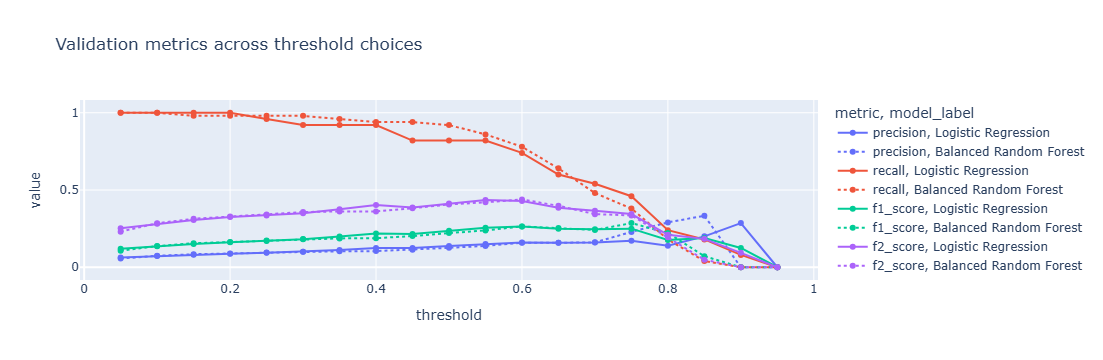

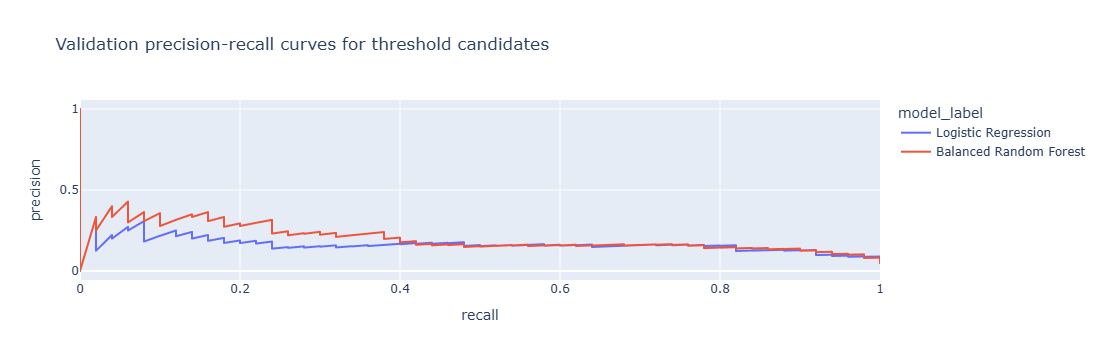

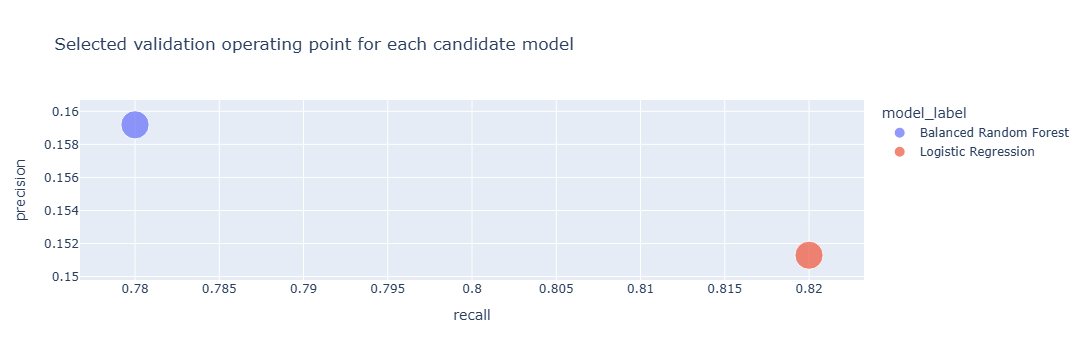

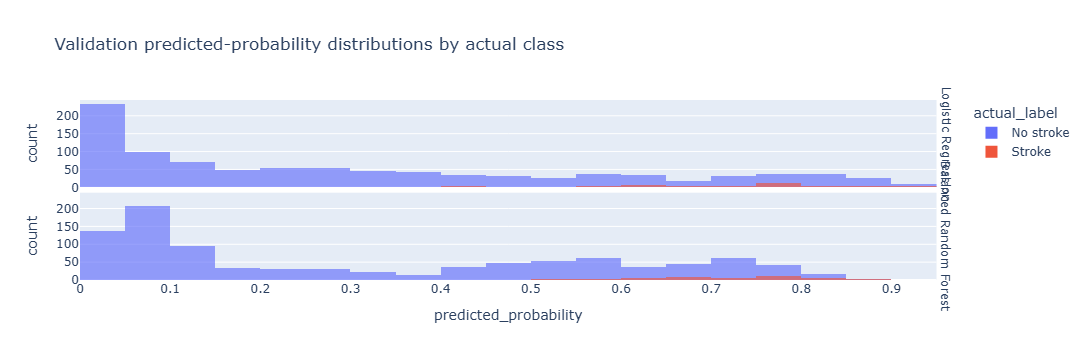

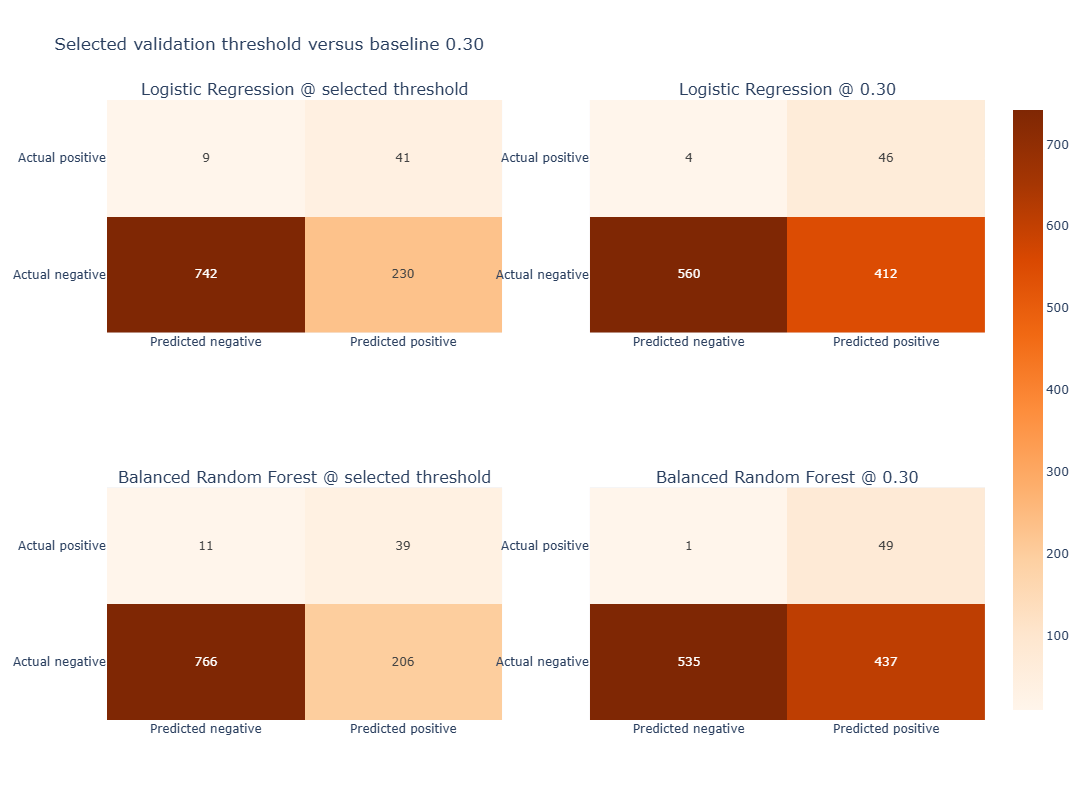

In [35]:
# Threshold analysis focuses on the strongest recall-first candidates.
# The aim is to show the tradeoff graphically, not just print one chosen value.
threshold_models = ["logistic", "balanced_rf"]
threshold_rows = []
pr_curve_rows = []
probability_rows = []

for model_key in threshold_models:
    model_config = MODEL_REGISTRY[model_key]
    probabilities = validation_probabilities[model_key]

    # Record threshold metrics on a dense grid so the tradeoff is easy to see.
    for threshold in THRESHOLD_GRID:
        metrics = compute_metrics(y_val, probabilities, threshold)
        threshold_rows.append({
            "model_key": model_key,
            "model_label": model_config["label"],
            "threshold": threshold,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1_score"],
            "f2_score": metrics["f2_score"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
            "tn": metrics["tn"],
            "confusion_matrix": metrics["confusion_matrix"],
        })

    # Precision-recall curves help show ranking quality without fixing a
    # single threshold too early.
    pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_val, probabilities)
    pr_curve_rows.extend([
        {
            "model_key": model_key,
            "model_label": model_config["label"],
            "precision": float(precision_value),
            "recall": float(recall_value),
        }
        for precision_value, recall_value in zip(pr_precision, pr_recall)
    ])

    # Probability-distribution plots make it easier to see how much overlap
    # exists between the positive and negative classes.
    for probability, target in zip(probabilities, y_val):
        probability_rows.append({
            "model_key": model_key,
            "model_label": model_config["label"],
            "predicted_probability": float(probability),
            "actual_label": "Stroke" if int(target) == 1 else "No stroke",
        })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df[["model_label", "threshold", "precision", "recall", "f1_score", "f2_score", "fp", "fn"]])

# Choose the threshold with the strongest recall-weighted F2 score.
# If multiple thresholds tie, prefer higher recall, then higher precision,
# then the lower threshold.
recommended_thresholds = (
    threshold_df.sort_values(
        ["model_label", "f2_score", "recall", "precision", "threshold"],
        ascending=[True, False, False, False, True],
    )
    .groupby("model_label", as_index=False)
    .first()
)
display(recommended_thresholds[["model_label", "threshold", "precision", "recall", "f1_score", "f2_score", "fp", "fn"]])

threshold_plot_df = threshold_df.melt(
    id_vars=["model_label", "threshold"],
    value_vars=["precision", "recall", "f1_score", "f2_score"],
    var_name="metric",
    value_name="value",
)
fig_threshold = px.line(
    threshold_plot_df,
    x="threshold",
    y="value",
    color="metric",
    line_dash="model_label",
    markers=True,
    title="Validation metrics across threshold choices",
)
fig_threshold.show()

pr_curve_df = pd.DataFrame(pr_curve_rows)
fig_pr = px.line(
    pr_curve_df,
    x="recall",
    y="precision",
    color="model_label",
    title="Validation precision-recall curves for threshold candidates",
)
fig_pr.show()

selected_threshold_points = recommended_thresholds.copy()
fig_selected = px.scatter(
    selected_threshold_points,
    x="recall",
    y="precision",
    color="model_label",
    size="f2_score",
    hover_data=["threshold", "f1_score", "f2_score", "fp", "fn"],
    title="Selected validation operating point for each candidate model",
)
fig_selected.show()

probability_df = pd.DataFrame(probability_rows)
fig_probability = px.histogram(
    probability_df,
    x="predicted_probability",
    color="actual_label",
    facet_row="model_label",
    barmode="overlay",
    opacity=0.65,
    nbins=25,
    title="Validation predicted-probability distributions by actual class",
)
fig_probability.for_each_annotation(lambda annotation: annotation.update(text=annotation.text.split("=")[-1]))
fig_probability.show()

selected_map = {row["model_label"]: row["confusion_matrix"] for _, row in recommended_thresholds.iterrows()}
default_map = {row["model_label"]: row["confusion_matrix"] for _, row in threshold_df[threshold_df["threshold"] == SCREENING_THRESHOLD].iterrows()}
fig_threshold_conf = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Logistic Regression @ selected threshold",
        f"Logistic Regression @ {SCREENING_THRESHOLD:0.2f}",
        "Balanced Random Forest @ selected threshold",
        f"Balanced Random Forest @ {SCREENING_THRESHOLD:0.2f}",
    ],
)
ordered_labels = ["Logistic Regression", "Balanced Random Forest"]
matrices = [selected_map[ordered_labels[0]], default_map[ordered_labels[0]], selected_map[ordered_labels[1]], default_map[ordered_labels[1]]]
for idx, matrix in enumerate(matrices, start=1):
    fig_threshold_conf.add_trace(
        go.Heatmap(
            z=matrix,
            x=["Predicted negative", "Predicted positive"],
            y=["Actual negative", "Actual positive"],
            text=matrix,
            texttemplate="%{text}",
            colorscale="Oranges",
            showscale=(idx == 1),
        ),
        row=(idx - 1) // 2 + 1,
        col=(idx - 1) % 2 + 1,
    )
fig_threshold_conf.update_layout(height=800, title_text="Selected validation threshold versus baseline 0.30")
fig_threshold_conf.show()

## Hyperparameter Tuning

The tuning pass is intentionally narrow. The goal is not benchmark chasing; the goal is to check whether a modest and defensible parameter sweep materially changes the validation ranking.

This section keeps the process disciplined:
- fit each candidate parameter set on `train`
- score it on `validation`
- rank parameter sets with recall first, then recall-weighted `F2`
- keep the test split untouched until the final section

After tuning, the notebook compares tuned models **and** thresholds together under one declared validation rule.

C:\Users\rkrb1\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning:

The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.

C:\Users\rkrb1\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning:

The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.

C:\Users\rkrb1\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning:

The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.

C:\Users\rkrb1\anaconda3\Lib\sit

,model_key,model_label,best_params,validation_precision,validation_recall,validation_f1,validation_roc_auc
1,balanced_rf,Balanced Random Forest,"{'max_depth': 6, 'min_samples_leaf': 3, 'n_est...",0.0992,0.9800,0.1801,0.8564
2,random_forest,Random Forest,"{'class_weight': 'balanced', 'max_depth': 4, '...",0.1037,0.9600,0.1871,0.8420
0,logistic,Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced'}",0.0996,0.9400,0.1801,0.8420
3,gradient_boosting,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.2609,0.1200,0.1644,0.8458


,model_key,model_label,baseline_recall,baseline_roc_auc,validation_recall,validation_roc_auc
0,balanced_rf,Balanced Random Forest,0.9800,0.8530,0.9800,0.8564
1,random_forest,Random Forest,0.9400,0.8330,0.9600,0.8420
2,logistic,Logistic Regression,0.9200,0.8407,0.9400,0.8420
3,gradient_boosting,Gradient Boosting,0.1200,0.8458,0.1200,0.8458


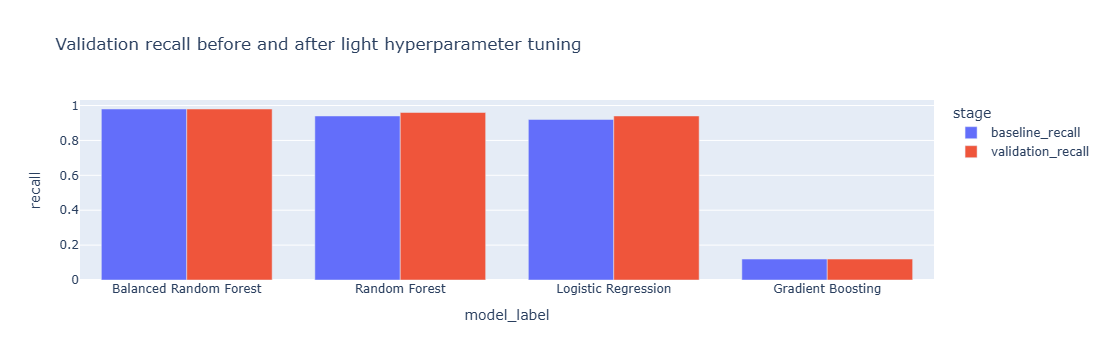

In [13]:
# Grid definitions stay small on purpose so the notebook remains interview-friendly.
# The point is to compare sensible variations, not exhaust every possibility.
param_grids = {
    "logistic": {"C": [0.1, 1.0, 10.0], "class_weight": ["balanced"]},
    "balanced_rf": {"n_estimators": [100, 200], "max_depth": [4, 6, 8], "min_samples_leaf": [3, 5, 10]},
    "random_forest": {"n_estimators": [100, 200], "max_depth": [4, 6, 8], "min_samples_leaf": [3, 5, 10], "class_weight": ["balanced"]},
    "gradient_boosting": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]},
}

tuning_rows = []
tuned_models = {}

for model_key, model_config in MODEL_REGISTRY.items():
    X_train_current = X_train_linear if model_config["uses_scaled_features"] else X_train_tree
    X_eval_current = X_val_linear if model_config["uses_scaled_features"] else X_val_tree
    best_result = None
    best_model = None

    # Evaluate every parameter combination on validation.
    for params in ParameterGrid(param_grids[model_key]):
        candidate = model_config["factory"]()
        candidate.set_params(**params)
        metrics, fitted_candidate, _ = evaluate_model(
            candidate,
            X_train_current,
            X_eval_current,
            y_train,
            y_val,
            threshold=SCREENING_THRESHOLD,
        )
        candidate_result = {
            "params": params,
            "validation_precision": metrics["precision"],
            "validation_recall": metrics["recall"],
            "validation_f1": metrics["f1_score"],
            "validation_f2": metrics["f2_score"],
            "validation_roc_auc": metrics["roc_auc"],
            "validation_average_precision": metrics["average_precision"],
        }

        # Ranking remains recall-first, but F2 helps avoid picking a setting
        # that gains recall only by letting precision collapse too far.
        if best_result is None or (
            candidate_result["validation_recall"],
            candidate_result["validation_f2"],
            candidate_result["validation_average_precision"],
            candidate_result["validation_precision"],
        ) > (
            best_result["validation_recall"],
            best_result["validation_f2"],
            best_result["validation_average_precision"],
            best_result["validation_precision"],
        ):
            best_result = candidate_result
            best_model = fitted_candidate

    tuned_models[model_key] = best_model
    tuning_rows.append({
        "model_key": model_key,
        "model_label": model_config["label"],
        "best_params": best_result["params"],
        "validation_precision": best_result["validation_precision"],
        "validation_recall": best_result["validation_recall"],
        "validation_f1": best_result["validation_f1"],
        "validation_f2": best_result["validation_f2"],
        "validation_roc_auc": best_result["validation_roc_auc"],
        "validation_average_precision": best_result["validation_average_precision"],
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    ["validation_recall", "validation_f2", "validation_average_precision"],
    ascending=[False, False, False],
)
display(tuning_df)

tuning_compare_df = comparison_df[["model_key", "model_label", "recall", "f2_score", "average_precision"]].rename(
    columns={
        "recall": "baseline_recall",
        "f2_score": "baseline_f2",
        "average_precision": "baseline_average_precision",
    }
)
tuning_compare_df = tuning_compare_df.merge(
    tuning_df[["model_key", "validation_recall", "validation_f2", "validation_average_precision"]],
    on="model_key",
    how="left",
)
display(tuning_compare_df)

fig_tuning = px.bar(
    tuning_compare_df.melt(
        id_vars=["model_label"],
        value_vars=["baseline_recall", "validation_recall", "baseline_f2", "validation_f2"],
        var_name="stage",
        value_name="value",
    ),
    x="model_label",
    y="value",
    color="stage",
    barmode="group",
    title="Validation recall and F2 before and after light hyperparameter tuning",
)
fig_tuning.show()

## Interpretability

This section keeps the explanation layer simple and honest:
- Logistic regression uses signed coefficients, which are easy to discuss as a baseline.
- Tree models use feature importance, which is useful for global ranking but is not a patient-level explanation.

The code comments below explain what each table and chart is showing.

,feature,coefficient,abs_coefficient
0,age,1.6641,1.6641
7,smoking_status_smokes,0.5149,0.5149
1,hypertension,0.4073,0.4073
6,smoking_status_formerly smoked,0.3253,0.3253
3,avg_glucose_level,0.2397,0.2397
8,smoking_status_Unknown,0.1967,0.1967
2,heart_disease,0.1171,0.1171
5,gender_other,-0.0033,0.0033
4,bmi,-0.0016,0.0016


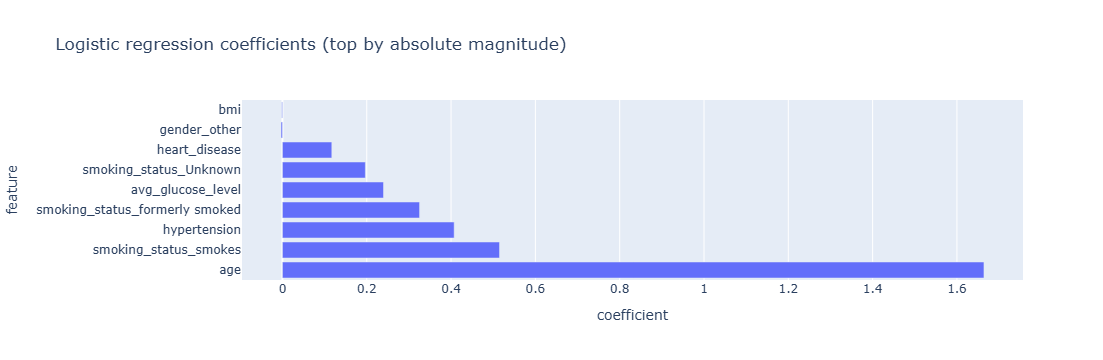

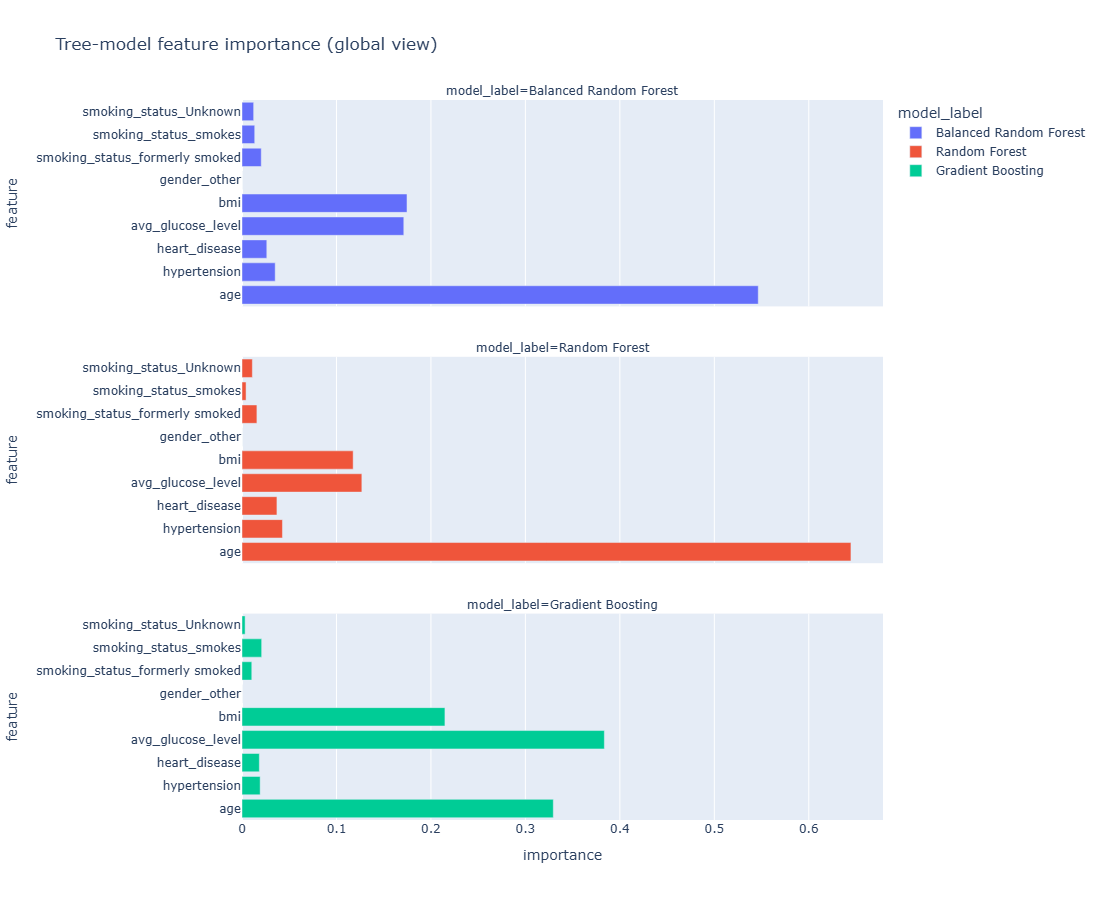

In [38]:
# Start with the tuned logistic model if tuning was run; otherwise fall back to
# the untuned fitted model. This keeps the interpretation aligned with the
# strongest version of the linear baseline shown earlier in the notebook.
logistic_model = tuned_models.get("logistic", fitted_models["logistic"])

# Coefficients show the direction and relative strength of each feature in the
# linear model. Larger absolute magnitude means a stronger global effect.
logistic_coefficients = pd.DataFrame({
    "feature": X_train_linear.columns,
    "coefficient": logistic_model.coef_[0],
})
logistic_coefficients["abs_coefficient"] = logistic_coefficients["coefficient"].abs()
logistic_coefficients = logistic_coefficients.sort_values("abs_coefficient", ascending=False)
display(logistic_coefficients)

fig_coef = px.bar(
    logistic_coefficients.head(10),
    x="coefficient",
    y="feature",
    orientation="h",
    title="Logistic regression coefficients (top by absolute magnitude)",
)
fig_coef.show()

# Tree models do not provide simple signed coefficients, so use feature
# importance as a global ranking signal instead.
tree_importance_rows = []
for model_key in ["balanced_rf", "random_forest", "gradient_boosting"]:
    model = tuned_models.get(model_key, fitted_models[model_key])
    for feature_name, importance in zip(X_train_tree.columns, model.feature_importances_):
        tree_importance_rows.append({
            "model_label": MODEL_REGISTRY[model_key]["label"],
            "feature": feature_name,
            "importance": float(importance),
        })

tree_importance_df = pd.DataFrame(tree_importance_rows)
fig_tree = px.bar(
    tree_importance_df,
    x="importance",
    y="feature",
    color="model_label",
    facet_col="model_label",
    facet_col_wrap=1,
    orientation="h",
    height=900,
    title="Tree-model feature importance (global view)",
)
fig_tree.show()

In [ ]:
# Final operating-point selection happens only after tuning.
# This cell compares every tuned model across the threshold grid on validation,
# then creates a short nearby-threshold shortlist for business review.

display(Markdown(
    "**Validation ranking rule for final operating points:** "
    "highest recall, then highest `F2`, then highest average precision, then highest precision."
))

tuned_validation_probabilities = {}
operating_point_rows = []

for model_key, model_config in MODEL_REGISTRY.items():
    tuned_model = tuned_models[model_key]
    X_eval_current = X_val_linear if model_config["uses_scaled_features"] else X_val_tree
    probabilities = tuned_model.predict_proba(X_eval_current)[:, 1]
    tuned_validation_probabilities[model_key] = probabilities

    for threshold in THRESHOLD_GRID:
        metrics = compute_metrics(y_val, probabilities, float(threshold))
        operating_point_rows.append({
            "model_key": model_key,
            "model_label": model_config["label"],
            "threshold": float(threshold),
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1_score"],
            "f2_score": metrics["f2_score"],
            "roc_auc": metrics["roc_auc"],
            "average_precision": metrics["average_precision"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
            "tn": metrics["tn"],
            "confusion_matrix": metrics["confusion_matrix"],
        })

operating_point_df = pd.DataFrame(operating_point_rows).sort_values(
    ["recall", "f2_score", "average_precision", "precision"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

display(
    operating_point_df[
        ["model_label", "threshold", "precision", "recall", "f1_score", "f2_score", "average_precision", "fp", "fn"]
    ].head(12)
)

best_operating_point = operating_point_df.iloc[0]
selected_model_key = str(best_operating_point["model_key"])
selected_model_label = str(best_operating_point["model_label"])
selected_threshold = float(best_operating_point["threshold"])
selected_model_params = tuning_df.set_index("model_key").loc[selected_model_key, "best_params"]

best_alternative_point = operating_point_df[operating_point_df["model_key"] != selected_model_key].iloc[0]

# Build a shortlist of nearby thresholds for the winning model.
# The purpose is to preserve business choice among very similar operating points
# without pretending that one validation threshold is universally correct.
model_thresholds = sorted(
    operating_point_df.loc[operating_point_df["model_key"] == selected_model_key, "threshold"].unique().tolist()
)
selected_index = model_thresholds.index(selected_threshold)
nearby_indices = sorted(set(index for index in [selected_index - 1, selected_index, selected_index + 1] if 0 <= index < len(model_thresholds)))
nearby_thresholds = [model_thresholds[index] for index in nearby_indices]

shortlist_df = (
    operating_point_df[
        (operating_point_df["model_key"] == selected_model_key)
        & (operating_point_df["threshold"].isin(nearby_thresholds))
    ]
    .sort_values("threshold")
    .reset_index(drop=True)
)
shortlist_df.insert(0, "candidate_id", [f"C{index + 1}" for index in range(len(shortlist_df))])

display(
    shortlist_df[
        ["candidate_id", "model_label", "threshold", "precision", "recall", "f1_score", "f2_score", "average_precision", "fp", "fn"]
    ]
)

fig_operating_points = px.scatter(
    operating_point_df,
    x="recall",
    y="precision",
    color="model_label",
    size="f2_score",
    hover_data=["threshold", "average_precision", "fp", "fn"],
    title="Validation operating points across tuned models and thresholds",
)
fig_operating_points.show()

shortlist_plot_df = shortlist_df.melt(
    id_vars=["candidate_id", "threshold"],
    value_vars=["precision", "recall", "f2_score"],
    var_name="metric",
    value_name="value",
)
fig_shortlist = px.line(
    shortlist_plot_df,
    x="threshold",
    y="value",
    color="metric",
    markers=True,
    title="Nearby-threshold shortlist for the selected model",
)
fig_shortlist.show()

decision_markdown = f"""
## Validation Operating-Point Summary

- **Declared ranking rule**: highest recall, then highest `F2`, then highest average precision, then highest precision.
- **Top tuned validation pair under that rule**: **{selected_model_label} @ {selected_threshold:0.2f}**.
- **Selected model hyperparameters**: **`{selected_model_params}`**.
- **Best alternative pair from another model**: **{best_alternative_point['model_label']} @ {float(best_alternative_point['threshold']):0.2f}**.
- **Business-review shortlist**: use the nearby-threshold candidate table above for the winning model before touching the test split.
"""
display(Markdown(decision_markdown))

## Final Holdout Test

Pick exactly one candidate from the shortlist above, then run the next cell once.

Do **not** use the holdout test split to compare multiple shortlist candidates. The shortlist exists so the business decision happens on validation, not on test.

In [ ]:
# Set these manually after reviewing the shortlist in the previous cell.
# Example:
# SELECTED_FINAL_MODEL_KEY = "balanced_rf"
# SELECTED_FINAL_THRESHOLD = 0.55
SELECTED_FINAL_MODEL_KEY = None
SELECTED_FINAL_THRESHOLD = None

if SELECTED_FINAL_MODEL_KEY is None or SELECTED_FINAL_THRESHOLD is None:
    raise ValueError(
        "Choose one shortlisted `(model, threshold)` pair from the previous cell before running the final holdout test."
    )

selected_model_config = MODEL_REGISTRY[SELECTED_FINAL_MODEL_KEY]
selected_params = tuning_df.set_index("model_key").loc[SELECTED_FINAL_MODEL_KEY, "best_params"]

# Rebuild preprocessing on train + validation before the final holdout test.
X_trainval_selected_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_trainval_selected = pd.concat([y_train, y_val], axis=0)

final_bmi_median, final_scaler = fit_preprocessor(X_trainval_selected_raw)
X_trainval_tree_final, X_trainval_linear_final = transform_with_preprocessor(
    X_trainval_selected_raw,
    final_bmi_median,
    final_scaler,
)
X_test_tree_final, X_test_linear_final = transform_with_preprocessor(
    X_test_raw,
    final_bmi_median,
    final_scaler,
)

final_model = selected_model_config["factory"]()
final_model.set_params(**selected_params)
X_train_final = X_trainval_linear_final if selected_model_config["uses_scaled_features"] else X_trainval_tree_final
X_test_final = X_test_linear_final if selected_model_config["uses_scaled_features"] else X_test_tree_final
final_model.fit(X_train_final, y_trainval_selected)

# Evaluate the untouched test split once using the manually chosen operating point.
final_probabilities = final_model.predict_proba(X_test_final)[:, 1]
final_test_metrics = compute_metrics(y_test, final_probabilities, threshold=float(SELECTED_FINAL_THRESHOLD))

final_summary_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "f2_score",
            "roc_auc",
            "average_precision",
            "threshold",
            "false_positives",
            "false_negatives",
        ],
        "value": [
            final_test_metrics["accuracy"],
            final_test_metrics["precision"],
            final_test_metrics["recall"],
            final_test_metrics["f1_score"],
            final_test_metrics["f2_score"],
            final_test_metrics["roc_auc"],
            final_test_metrics["average_precision"],
            float(SELECTED_FINAL_THRESHOLD),
            final_test_metrics["fp"],
            final_test_metrics["fn"],
        ],
    }
)
display(final_summary_df)

final_markdown = f"""
## Final Holdout Result

- **Chosen model**: **{MODEL_REGISTRY[SELECTED_FINAL_MODEL_KEY]['label']}**
- **Chosen hyperparameters**: **`{selected_params}`**
- **Chosen threshold**: **{float(SELECTED_FINAL_THRESHOLD):0.2f}**
- **Test recall**: **{final_test_metrics['recall']:0.4f}**
- **Test precision**: **{final_test_metrics['precision']:0.4f}**
- **Test F2**: **{final_test_metrics['f2_score']:0.4f}**
"""
display(Markdown(final_markdown))

fig_final_conf = go.Figure(
    data=go.Heatmap(
        z=final_test_metrics["confusion_matrix"],
        x=["Predicted negative", "Predicted positive"],
        y=["Actual negative", "Actual positive"],
        text=final_test_metrics["confusion_matrix"],
        texttemplate="%{text}",
        colorscale="Greens",
    )
)
fig_final_conf.update_layout(title_text="Final holdout test confusion matrix")
fig_final_conf.show()